In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures


In [2]:
df = pd.read_csv('housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
dir(df)

In [ ]:
df.duplicated()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.shape

(545, 13)

In [5]:
df = pd.read_csv('housing.csv')
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes': 1, 'no': 0})
df['airconditioning'] = df['airconditioning'].map({'yes': 1, 'no': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':2, 'semi-furnished': 1, 'unfurnished': 0})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'mainroad'}>,
        <Axes: title={'center': 'guestroom'}>,
        <Axes: title={'center': 'basement'}>],
       [<Axes: title={'center': 'hotwaterheating'}>,
        <Axes: title={'center': 'airconditioning'}>,
        <Axes: title={'center': 'parking'}>,
        <Axes: title={'center': 'prefarea'}>],
       [<Axes: title={'center': 'furnishingstatus'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

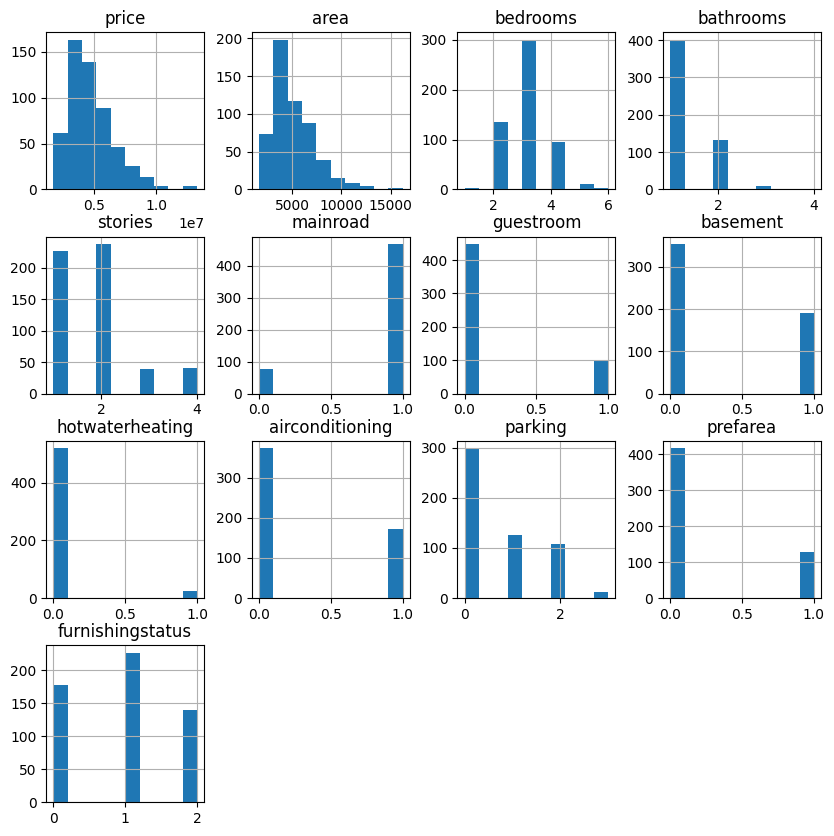

In [6]:
df.hist(figsize=(10,10))

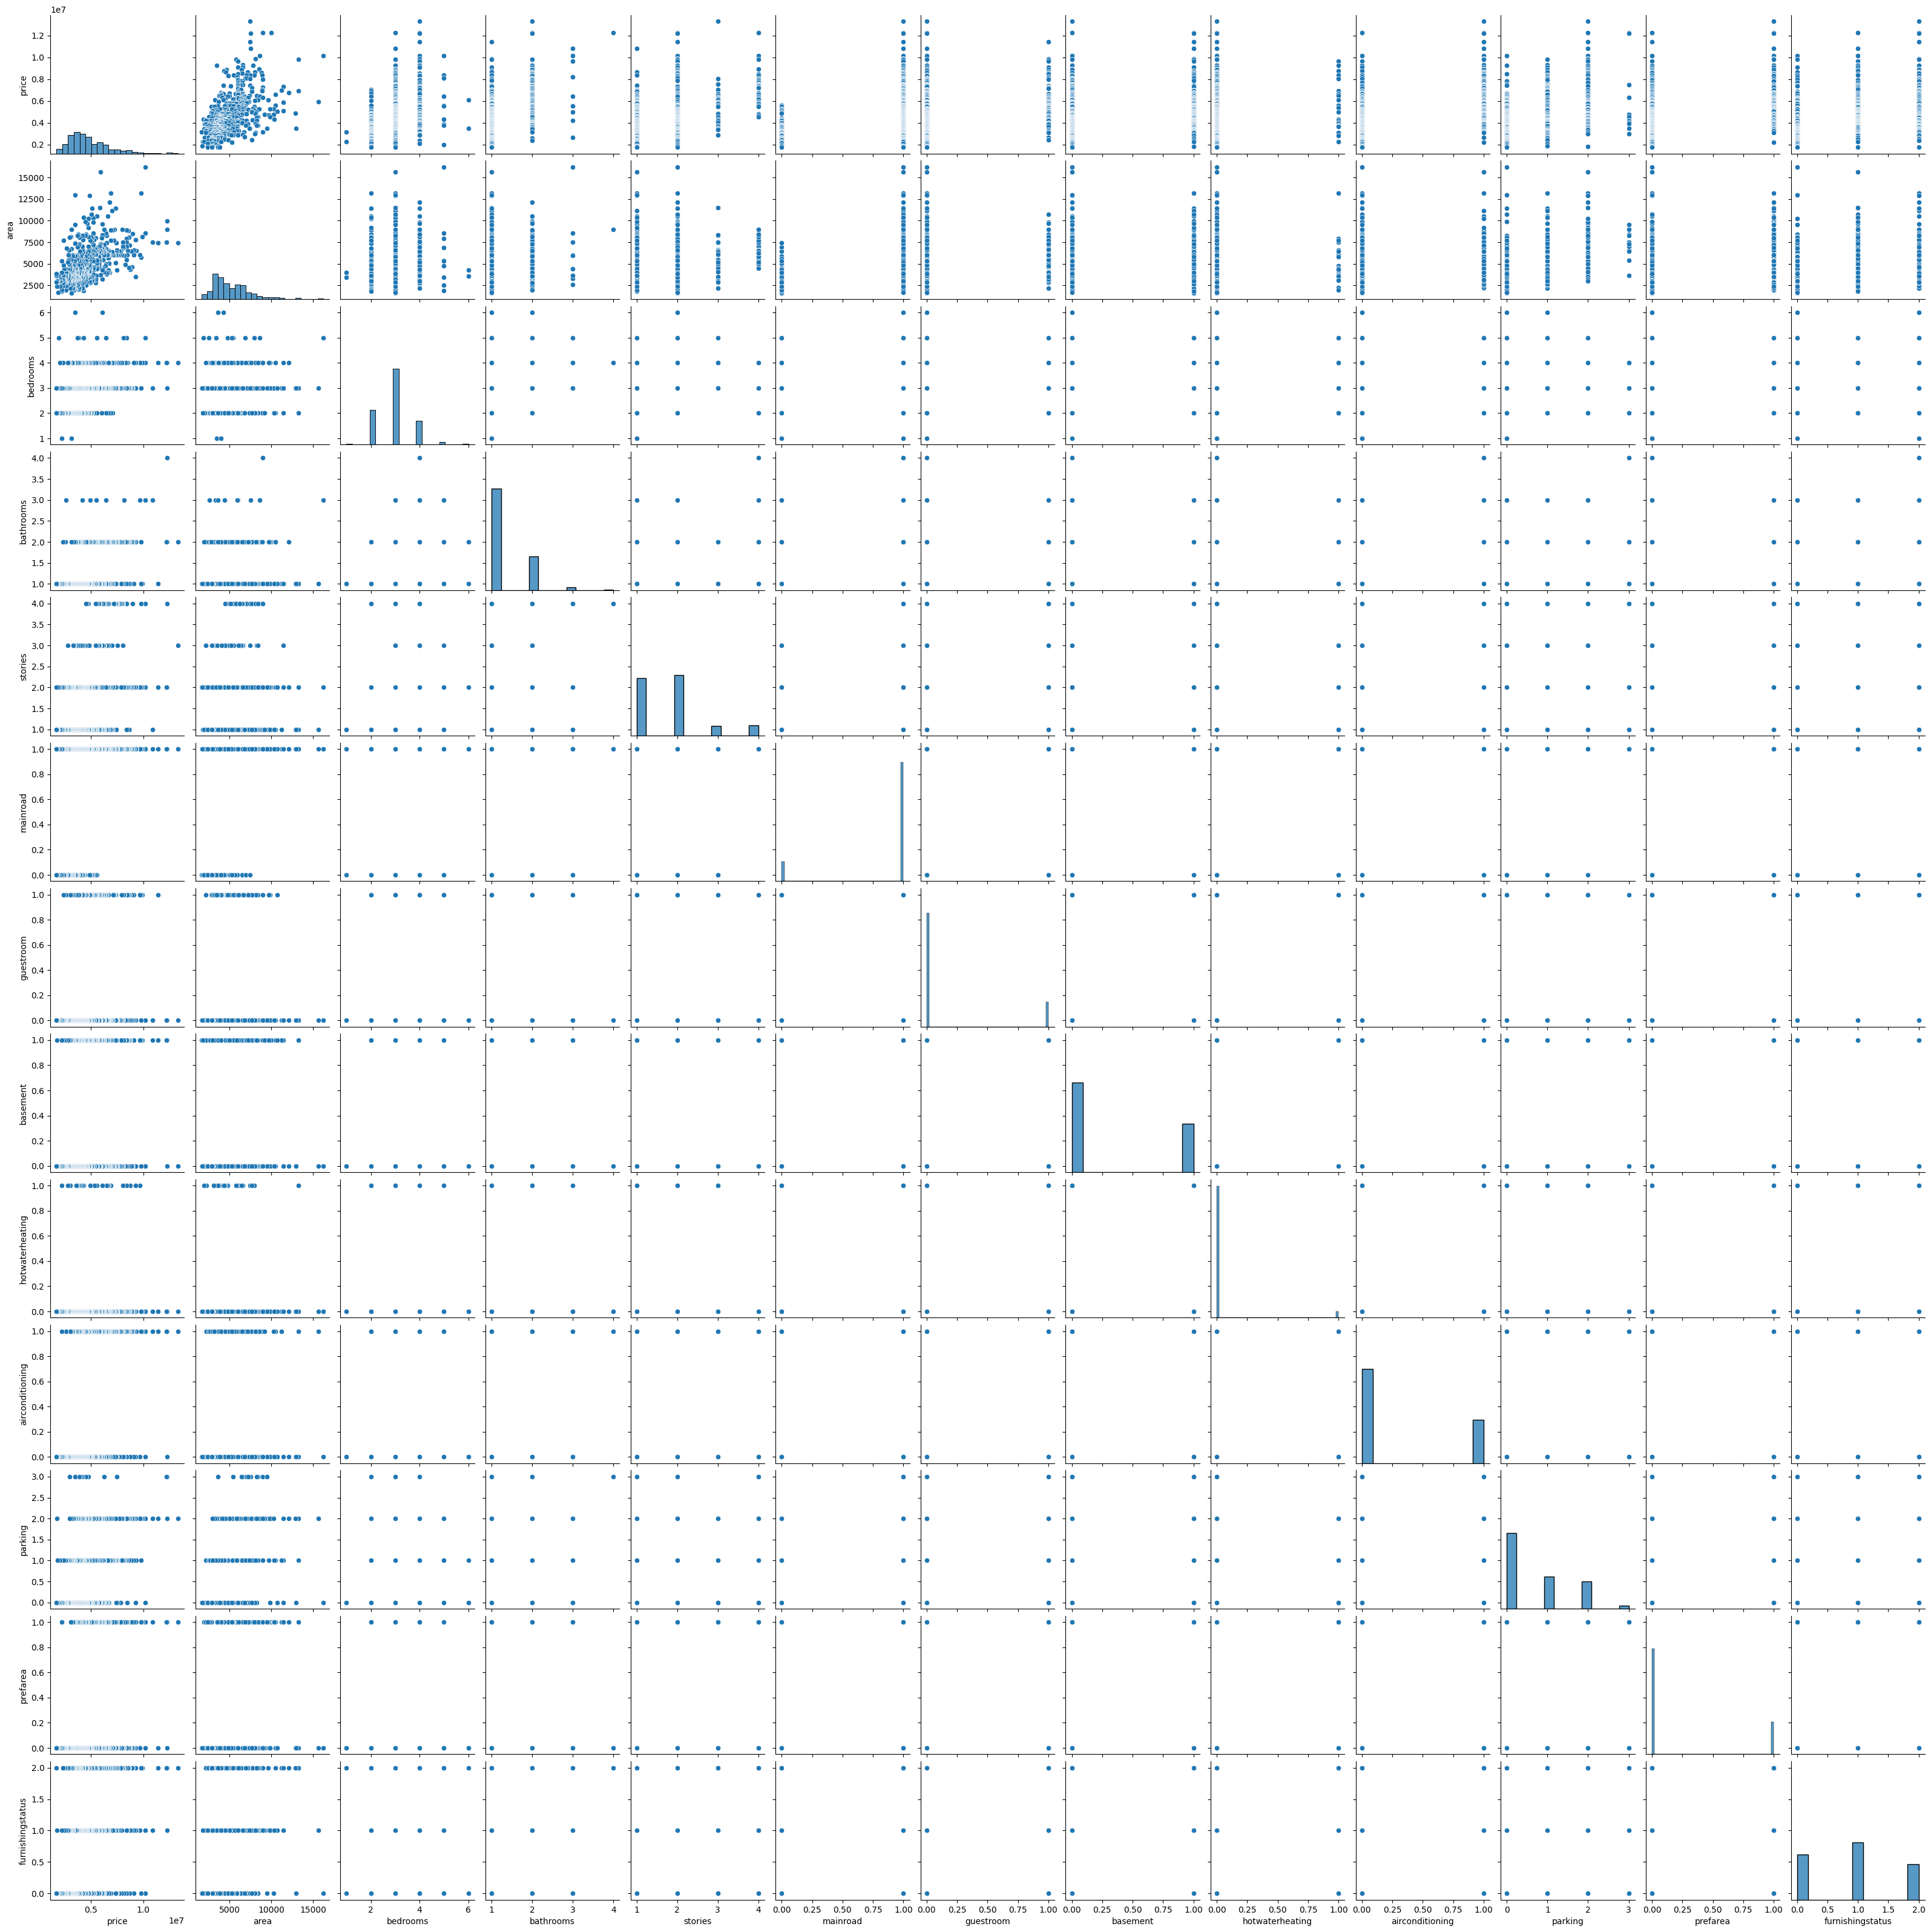

In [7]:
sns.pairplot(df)

<Axes: >

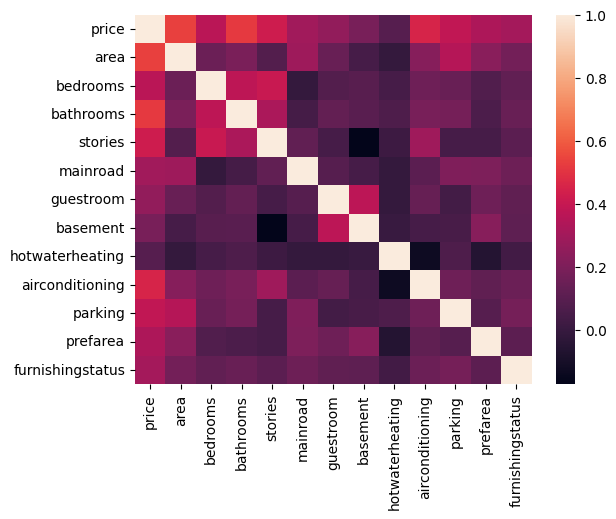

In [8]:
sns.heatmap(df.corr(method="pearson"))

In [12]:
print(df.corr(method='pearson'))
print("Sum: ", (df.corr(method='pearson') == 0).sum().sum())

                     price      area  bedrooms  bathrooms   stories  mainroad  \
price             1.000000  0.535997  0.366494   0.517545  0.420712  0.296898   
area              0.535997  1.000000  0.151858   0.193820  0.083996  0.288874   
bedrooms          0.366494  0.151858  1.000000   0.373930  0.408564 -0.012033   
bathrooms         0.517545  0.193820  0.373930   1.000000  0.326165  0.042398   
stories           0.420712  0.083996  0.408564   0.326165  1.000000  0.121706   
mainroad          0.296898  0.288874 -0.012033   0.042398  0.121706  1.000000   
guestroom         0.255517  0.140297  0.080549   0.126469  0.043538  0.092337   
basement          0.187057  0.047417  0.097312   0.102106 -0.172394  0.044002   
hotwaterheating   0.093073 -0.009229  0.046049   0.067159  0.018847 -0.011781   
airconditioning   0.452954  0.222393  0.160603   0.186915  0.293602  0.105423   
parking           0.384394  0.352980  0.139270   0.177496  0.045547  0.204433   
prefarea          0.329777  

In [ ]:
def normalize(X):
    print("Mean Before: ", X.mean(axis=0), "\nStd dev. Before: ", X.std(axis=0))

    sc = StandardScaler()
    XScaled = sc.fit_transform(X)

    print("Mean After: ",XScaled.mean(axis=0), "\nStd dev. After: ",XScaled.std(axis=0))
    return XScaled

In [14]:
def splitTrainTest(X, Y, seed, splitRatio):
    X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=seed, test_size=splitRatio)
    # print("Dimensions: ")
    # print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    return X_train,X_test,y_train,y_test


In [15]:
features = df.columns[1:]
# features = df.columns[1] for UNIVARIATE
X = df[features].values
Y = df['price'].values

XScaled = normalize(X)

Mean Before:  [5.15054128e+03 2.96513761e+00 1.28623853e+00 1.80550459e+00
 8.58715596e-01 1.77981651e-01 3.50458716e-01 4.58715596e-02
 3.15596330e-01 6.93577982e-01 2.34862385e-01 9.30275229e-01] 
Std dev. Before:  [2.16814915e+03 7.37386427e-01 5.02008423e-01 8.66696233e-01
 3.48314687e-01 3.82497298e-01 4.77113618e-01 2.09206500e-01
 4.64752931e-01 8.60794942e-01 4.23912780e-01 7.60673843e-01]
Mean After:  [-1.56449777e-16 -1.82524739e-16 -2.60749628e-17 -1.30374814e-16
 -1.82524739e-16  5.21499256e-17 -7.82248883e-17 -6.51874070e-18
 -5.21499256e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00] 
Std dev. After:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
def plotRegressionLine(X, Y, w, b):
    plt.scatter(x = X, y = Y)
    plt.plot(X, w*X+b, 'g-')
    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.show()

In [24]:
def LinReg(XScaled, Y):
    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(XScaled, Y, seed=4, splitRatio=0.2)

    print("*************Learning/Fitting the model on training partition*************")
    LRModel = LinearRegression()
    LRModel.fit(X_train,Y_train)
    print('Features used: ', features)
    print("Weight/Slope W:", LRModel.coef_)
    print("Bias/Intercept B:", LRModel.intercept_)

    print("*************Plotting Regression MODEL Learned if univariate *************")
    if X.shape[1] == 1:
        plotRegressionLine(X_train, Y_train, LRModel.coef_, LRModel.intercept_)

    print("*************Evaluating performance of trained model on test partition*************")
    Y_pred = LRModel.predict(X_test)
    print('MAE:', metrics.mean_absolute_error(Y_test, Y_pred))
    print('MSE:', metrics.mean_squared_error(Y_test, Y_pred))
    print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
    print('R2 SCore:', metrics.r2_score(Y_test, Y_pred))

In [ ]:
def polyReg(XScaled, Y, degree):
    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(XScaled, Y, seed=4, splitRatio=0.2)

    print("*************Learning/Fitting the model on training partition*************")
    
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train)
    LRModel = LinearRegression()
    LRModel.fit(X_poly,Y_train)
    print('Features used: ', features)
    print("Weight/Slope W:", LRModel.coef_)
    print("Bias/Intercept B:", LRModel.intercept_)

    print("*************Evaluating performance of trained model on test partition*************")
    X_test_poly = poly.transform(X_test)
    Y_pred = LRModel.predict(X_test_poly)
    print('MAE:', metrics.mean_absolute_error(Y_test, Y_pred))
    print('MSE:', metrics.mean_squared_error(Y_test, Y_pred))
    print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
    print('R2 SCore:', metrics.r2_score(Y_test, Y_pred))

In [ ]:
def lassoAndRidgeReg(XScaled, Y):
    print("*************Train-Test Split*************")
    X_train, X_test, Y_train, Y_test = splitTrainTest(XScaled, Y, seed=2, splitRatio=0.2)

    print("*************Learning/Fitting the model on training partition*************")
    
    lassoModel = Lasso(alpha=0.1)
    ridgeModel = Ridge(alpha=0.1)
    lassoModel.fit(X_train,Y_train)
    ridgeModel.fit(X_train,Y_train)
    print('Features used: ', features)
    print("Lasso Regression - Weight/Slope W:", lassoModel.coef_)
    print("Lasso Regression - Bias/Intercept B:", lassoModel.intercept_)
    print("Ridge Regression - Weight/Slope W:", ridgeModel.coef_)
    print("Ridge Regression - Bias/Intercept B:", ridgeModel.intercept_)

    print("*************Evaluating performance of trained model on test partition*************")
    Y_pred_lasso = lassoModel.predict(X_test)
    Y_pred_ridge = ridgeModel.predict(X_test)
    print('Lasso Regression - MAE:', metrics.mean_absolute_error(Y_test, Y_pred_lasso))
    print('Lasso Regression - MSE:', metrics.mean_squared_error(Y_test, Y_pred_lasso))
    print('Lasso Regression - RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_lasso)))
    print('Lasso Regression - R2 SCore:', metrics.r2_score(Y_test, Y_pred_lasso))
    print('Ridge Regression - MAE:', metrics.mean_absolute_error(Y_test, Y_pred_ridge))
    print('Ridge Regression - MSE:', metrics.mean_squared_error(Y_test, Y_pred_ridge))
    print('Ridge Regression - RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_ridge)))
    print('Ridge Regression - R2 SCore:', metrics.r2_score(Y_test, Y_pred_ridge))

##  **QUESTION2_Simple Linear Regression multiple linear regression**

In [25]:
LinReg(XScaled, Y)

*************Train-Test Split*************
*************Learning/Fitting the model on training partition*************
Features used:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')
Weight/Slope W: [579197.23031398 100291.94502116 487611.98679351 433571.6490238
 155255.36993645  89007.26837239 200359.1594082  197114.58561835
 350767.86705845 250281.45250287 233304.6653157  142205.15660839]
Bias/Intercept B: 4777527.137839422
*************Plotting Regression MODEL Learned if univariate *************
*************Evaluating performance of trained model on test partition*************
MAE: 753572.2014385099
MSE: 1052021000187.0787
RMSE: 1025680.7496424405
R2 SCore: 0.6705158123115076


##  **QUESTION 3. Polynomial Regression**

In [23]:
polyReg(XScaled, Y, degree=3)

*************Train-Test Split*************
*************Learning/Fitting the model on training partition*************
Features used:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')
Weight/Slope W: [ 7.30797183e-08  2.89942849e+05  2.86290222e+05  2.35262413e+05
  9.19909532e+04 -6.58423346e+03  3.70727113e+04  8.56393499e+04
 -3.43859899e+01  6.65487792e+04  7.11968303e+04  8.36563844e+04
  5.50433851e+04 -4.65650944e+05 -3.59819683e+05  1.90970660e+05
  1.21022128e+05  4.78375404e+04 -2.51383709e+05  1.45716620e+05
 -8.72382290e+04 -2.84954663e+04  3.44471454e+05 -9.63424470e+04
  3.77574503e+05  1.63268564e+05 -2.98159721e+05  2.27093096e+03
  2.43344109e+05  2.45459481e+05 -6.90172795e+05 -4.76476857e+04
 -1.47249484e+05  3.92375582e+05 -1.21205695e+05 -3.21792288e+05
  1.09933230e+05 -3.49054414e+04  9.33202619e+04  2.2798800

## **QUESTION 4. Lasso and Ridge Regression For Multiple Polynomial Regression**

In [29]:
lassoAndRidgeReg(XScaled, Y)

*************Train-Test Split*************
*************Learning/Fitting the model on training partition*************
Features used:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')
Lasso Regression - Weight/Slope W: [535675.14938879  46358.30463571 480382.71945204 390679.60599535
 134173.67733534 132789.79136565 190964.82891565 171502.7060561
 397431.59002566 235978.48419768 298261.14964221 208841.38210091]
Lasso Regression - Bias/Intercept B: 4743692.53849972
Ridge Regression - Weight/Slope W: [535572.63402444  46437.54343518 480301.37491707 390602.75257416
 134193.9465514  132813.30150441 190916.97117876 171456.78353947
 397385.41022633 235974.21406685 298235.18715906 208833.61044244]
Ridge Regression - Bias/Intercept B: 4743691.250073887
*************Evaluating performance of trained model on test partition*************
Lasso 